# S&P 500 Momentum Trading Backtest

**Objective:** Build a momentum backtester using 10 years of daily OHLCV data.  
**Deliverables:** Best sector regime, worst drawdown, Sharpe ratio, and interpretation.

In [46]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Load sectors
sectors = pd.read_csv('archive (1)/sp500_companies.csv')
sectors.columns = sectors.columns.str.lower()
sectors = sectors[['symbol', 'sector']].drop_duplicates()

# Load prices
prices = pd.read_csv('archive (1)/sp500_stocks.csv')
prices.columns = prices.columns.str.lower()
prices['date'] = pd.to_datetime(prices['date'])
prices = prices[['date', 'symbol', 'open', 'high', 'low', 'close', 'volume']]

# Merge sectors and clean
prices = prices.merge(sectors, on='symbol', how='left')
prices = prices.dropna(subset=['date', 'symbol', 'close', 'sector'])
prices = prices.drop_duplicates(subset=['date', 'symbol'])
prices = prices.sort_values(['symbol', 'date']).reset_index(drop=True)
prices['adj_close'] = prices['close']
prices.info()
print(f"Data loaded: {len(prices):,} rows")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 617831 entries, 0 to 617830
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   date       617831 non-null  datetime64[ns]
 1   symbol     617831 non-null  object        
 2   open       617831 non-null  float64       
 3   high       617831 non-null  float64       
 4   low        617831 non-null  float64       
 5   close      617831 non-null  float64       
 6   volume     617831 non-null  float64       
 7   sector     617831 non-null  object        
 8   adj_close  617831 non-null  float64       
dtypes: datetime64[ns](1), float64(6), object(2)
memory usage: 42.4+ MB
Data loaded: 617,831 rows


In [57]:

prices.head()

,date,symbol,open,high,low,close,volume,sector,adj_close
0,2013-01-02,ABBV,34.919998,35.400002,34.099998,35.119999,13767900.0,Healthcare,35.119999
1,2013-01-03,ABBV,35.000000,35.000000,34.160000,34.830002,16739300.0,Healthcare,34.830002
2,2013-01-04,ABBV,34.619999,34.889999,34.250000,34.389999,21372100.0,Healthcare,34.389999
3,2013-01-07,ABBV,34.150002,35.450001,34.150002,34.459999,17897100.0,Healthcare,34.459999
4,2013-01-08,ABBV,34.290001,34.639999,33.360001,33.709999,17863300.0,Healthcare,33.709999


## Strategy & Metrics

In [48]:
# Daily returns and 126-day momentum
prices['daily_return'] = prices.groupby('symbol')['adj_close'].pct_change()
prices['momentum_126d'] = prices.groupby('symbol')['adj_close'].pct_change(126)

# Keep only valid signals
valid_data = prices.dropna(subset=['daily_return', 'momentum_126d']).copy()
print(f"Valid signals: {len(valid_data):,} rows")

# Rank and select top 20% by momentum each day
valid_data['momentum_rank'] = valid_data.groupby('date')['momentum_126d'].rank(pct=True)
top_20_percent = valid_data[valid_data['momentum_rank'] >= 0.8].copy()

# Calculate strategy daily returns
strategy_daily_returns = top_20_percent.groupby('date')['daily_return'].mean()
print(f"Strategy periods: {len(strategy_daily_returns)} days\n")

# Market regime: bull (>0) or bear (<0) based on 200-day trend
market_daily_returns = valid_data.groupby('date')['daily_return'].mean()
market_trend_200d = market_daily_returns.rolling(200).mean()
is_bull_market = np.where(market_trend_200d > 0, 'bull', 'bear')

# Sector performance by regime
sector_regime_data = top_20_percent.copy()
sector_regime_data['date_str'] = sector_regime_data['date'].astype(str)
market_dates = market_daily_returns.index.astype(str)
regime_by_date = dict(zip(market_dates, is_bull_market))
sector_regime_data['market_regime'] = sector_regime_data['date_str'].map(regime_by_date)

sector_performance = (
    sector_regime_data.dropna(subset=['market_regime'])
    .groupby(['sector', 'market_regime'])['daily_return'].mean()
    .dropna()
    .reset_index()
    .rename(columns={'daily_return': 'avg_return'})
    .sort_values('avg_return', ascending=False)
)

print("Top 10 sector-regime combos:")
print(sector_performance.head(10))

Valid signals: 596,159 rows
Strategy periods: 3642 days

Top 10 sector-regime combos:
                    sector regime      mean
19              Technology   bull  0.003209
5        Consumer Cyclical   bull  0.002992
18              Technology   bear  0.002984
1          Basic Materials   bull  0.002754
3   Communication Services   bull  0.002696
0          Basic Materials   bear  0.002693
15             Industrials   bull  0.002677
13              Healthcare   bull  0.002664
17             Real Estate   bull  0.002359
9                   Energy   bull  0.002357
Top 10 sector-regime combos:
                    sector regime      mean
19              Technology   bull  0.003209
5        Consumer Cyclical   bull  0.002992
18              Technology   bear  0.002984
1          Basic Materials   bull  0.002754
3   Communication Services   bull  0.002696
0          Basic Materials   bear  0.002693
15             Industrials   bull  0.002677
13              Healthcare   bull  0.002664
17   

In [49]:
# Calculate drawdown and metrics
cumulative_equity = (1 + strategy_daily_returns.fillna(0)).cumprod()
drawdown = (cumulative_equity - cumulative_equity.cummax()) / cumulative_equity.cummax()
max_drawdown = drawdown.min()
max_drawdown_date = drawdown.idxmin()

# Sharpe ratio (annualized)
clean_returns = strategy_daily_returns.dropna()
sharpe_ratio = (clean_returns.mean() / clean_returns.std()) * np.sqrt(252) if clean_returns.std() > 0 else np.nan

# Best performing sector
best_sector_row = sector_performance.iloc[0]
best_sector_name = best_sector_row['sector']
best_sector_regime = best_sector_row['market_regime']

# Report
print("\n" + "="*60)
print("TRADING STRATEGY REPORT")
print("="*60)
print(f"\n1. Best Sector: {best_sector_name} ({best_sector_regime})")
print(f"2. Max Drawdown: {max_drawdown:.2%} on {max_drawdown_date.date()}")
print(f"3. Sharpe Ratio: {sharpe_ratio:.2f}")
print("\n" + "="*60)


TRADING STRATEGY REPORT

1. Best Sector: Technology (bull)
2. Max Drawdown: -25.10% on 2020-03-16
3. Sharpe Ratio: 3.51



## Visualization

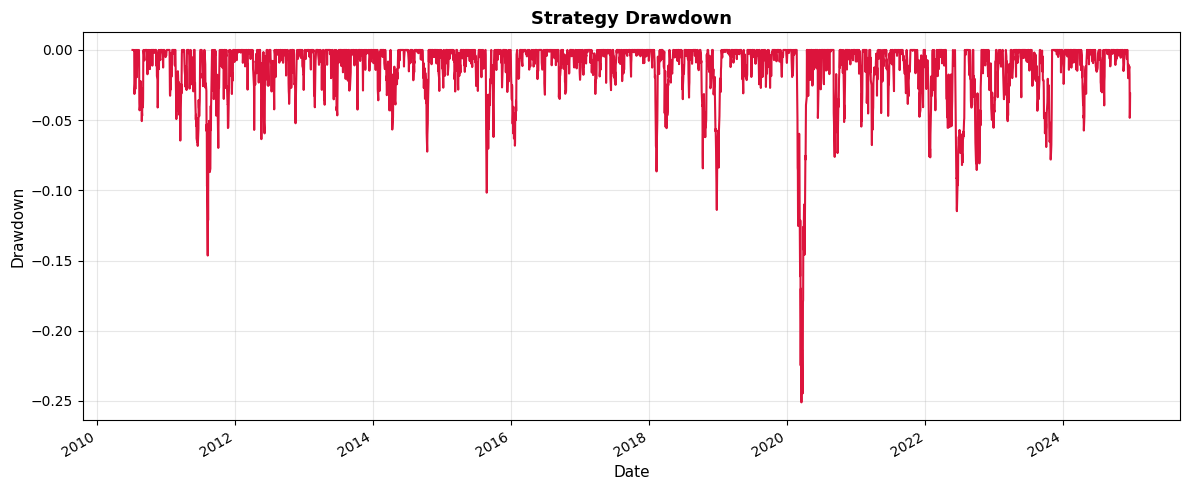

In [50]:
plt.figure(figsize=(12, 5))
drawdown.plot(color='crimson', linewidth=1.5)
plt.title('Strategy Drawdown', fontsize=13, fontweight='bold')
plt.ylabel('Drawdown', fontsize=11)
plt.xlabel('Date', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()